<a href="https://colab.research.google.com/github/joshua-y-hub/crisps/blob/main/MobineNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow

In [3]:
import tensorflow as tf
from keras import models,layers
import matplotlib.pyplot as plt
import os

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
dataset_path = "/content/drive/MyDrive/Potato_slices"
CHANNELS= 3

In [6]:
if os.path.exists(dataset_path):
    print(f"The directory '{dataset_path}' exists.")
else:
    print(f"The directory '{dataset_path}' does NOT exist. Please verify the path in your Google Drive.")
    print("You can list the contents of your Google Drive to find the correct path, for example:")
    print("  !ls /content/drive/MyDrive/")

The directory '/content/drive/MyDrive/Potato_slices' exists.


In [7]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle= True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 1456 files belonging to 2 classes.


In [8]:
class_names =dataset.class_names
class_names

['defected slices', 'healthy slices']

In [45]:
print(f"Class corresponding to label 0: {class_names[0]}")
print(f"Class corresponding to label 1: {class_names[1]}")

Class corresponding to label 0: defected slices
Class corresponding to label 1: healthy slices


In [9]:
print(f"Contents of {dataset_path}:")
for root, dirs, files in os.walk(dataset_path):
    # Print only immediate subdirectories and files in the root
    if root == dataset_path:
        if dirs:
            print(f"  Subdirectories: {dirs}")
        if files:
            print(f"  Files in root: {files}")
    print(f"  Found {len(files)} files in {root}")

# Count total image files
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp') # Common image extensions
total_image_files = 0
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            total_image_files += 1

print(f"Total image files found recursively: {total_image_files}")

Contents of /content/drive/MyDrive/Potato_slices:
  Subdirectories: ['healthy slices', 'defected slices']
  Found 0 files in /content/drive/MyDrive/Potato_slices
  Found 0 files in /content/drive/MyDrive/Potato_slices/healthy slices
  Found 718 files in /content/drive/MyDrive/Potato_slices/healthy slices/single
  Found 0 files in /content/drive/MyDrive/Potato_slices/defected slices
  Found 738 files in /content/drive/MyDrive/Potato_slices/defected slices/single
Total image files found recursively: 1456


In [10]:

len(dataset)

46

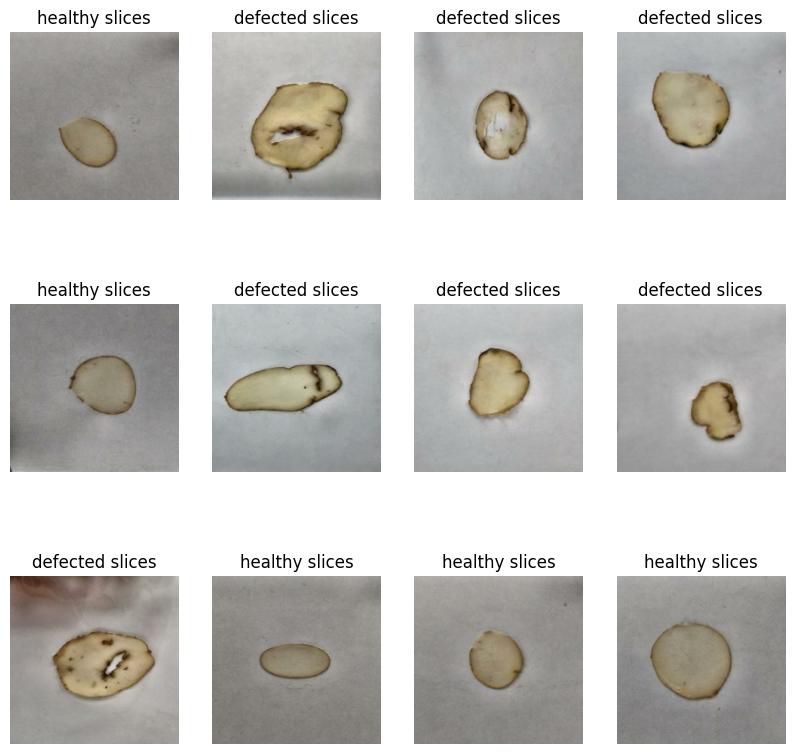

In [11]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range (12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [12]:
def get_dataset_partitions(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds= ds.shuffle(shuffle_size,seed=12)
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [13]:

train_ds,val_ds,test_ds=get_dataset_partitions(dataset)

In [14]:
len (train_ds)

36

In [15]:
len (val_ds)

4

In [16]:
len (test_ds)

6

In [47]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE) # Removed shuffle
test_ds = test_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE) # Removed shuffle

In [18]:

resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),  # Moved from experimental.preprocessing
    tf.keras.layers.Rescaling(1.0/255)  # Moved from experimental.preprocessing
])

In [46]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05), # Reduced from 0.1
    tf.keras.layers.RandomZoom(0.05),    # Reduced from 0.1
    tf.keras.layers.RandomBrightness(0.02), # Reduced from 0.05
    tf.keras.layers.RandomContrast(0.02),   # Reduced from 0.05
])

In [49]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7) # Adjusted factor and patience
]

In [50]:
input_shape = (BATCH_SIZE,IMAGE_SIZE, IMAGE_SIZE,CHANNELS)
n_classes= 2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=input_shape[1:], include_top=False, weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'), # Changed n_classes to 1
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(), # Instantiated
    metrics=['accuracy']
)
history=model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks) # Increased epochs

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.5278 - loss: 0.7971 - val_accuracy: 0.9688 - val_loss: 0.3539 - learning_rate: 1.0000e-04
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5764 - loss: 0.7131 - val_accuracy: 0.9766 - val_loss: 0.2422 - learning_rate: 1.0000e-04
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5816 - loss: 0.7038 - val_accuracy: 0.9766 - val_loss: 0.2069 - learning_rate: 1.0000e-04
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.6181 - loss: 0.6495 - val_accuracy: 0.9766 - val_loss: 0.1724 - learning_rate: 1.0000e-04
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6137 - loss: 0.6356 - val_accuracy: 0.9844 - val_loss: 0.1253 - learning_rate: 1.0000e-04
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6337 - loss: 0.6281 - val_accuracy: 0.9766 - val_loss: 0.1083 - learning_rate: 1.0000e-04
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy:

In [53]:
base_model.trainable = True
# Unfreeze all layers first, then freeze all but the last 30
for layer in base_model.layers[:-30]: # Adjust this number based on how many layers you want to unfreeze
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Revert to previous learning rate
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds, validation_data=val_ds, epochs=100,
    callbacks=callbacks
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.6875 - loss: 0.5392 - val_accuracy: 0.9922 - val_loss: 0.0429 - learning_rate: 1.0000e-04
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.7274 - loss: 0.4414 - val_accuracy: 0.9922 - val_loss: 0.0276 - learning_rate: 1.0000e-04
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.7352 - loss: 0.4004 - val_accuracy: 0.9922 - val_loss: 0.0258 - learning_rate: 1.0000e-04
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.7266 - loss: 0.4276 - val_accuracy: 0.9922 - val_loss: 0.0522 - learning_rate: 1.0000e-04
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7630 - loss: 0.3904 - val_accuracy: 0.9844 - val_loss: 0.0444 - learning_rate: 1.0000e-04
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7595 - loss: 0.3653 - val_accuracy: 0.9922 - val_loss: 0.0251 - learning_rate: 1.0000e-04
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy

In [54]:
acc_finetune = history_finetune.history['accuracy']
val_acc_finetune = history_finetune.history['val_accuracy']

loss_finetune = history_finetune.history['loss']
val_loss_finetune = history_finetune.history['val_loss']

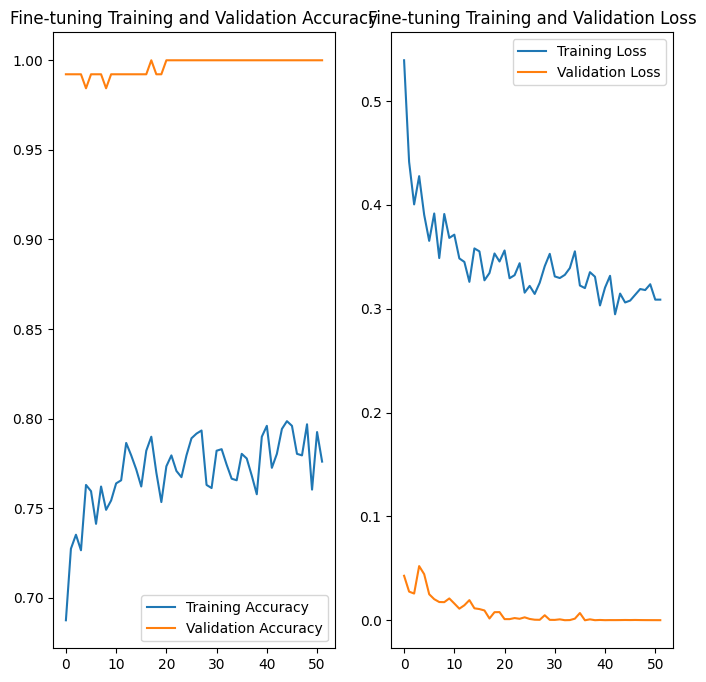

In [55]:
epochs_finetune = len(acc_finetune)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs_finetune),acc_finetune,label='Training Accuracy')
plt.plot(range(epochs_finetune),val_acc_finetune,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Fine-tuning Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(epochs_finetune),loss_finetune,label='Training Loss')
plt.plot(range(epochs_finetune),val_loss_finetune,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Fine-tuning Training and Validation Loss')
plt.show()

In [56]:
test_loss_finetune, test_acc_finetune = model.evaluate(test_ds)
print(f"Fine-tuned Test accuracy: {test_acc_finetune:.4f}, Test loss: {test_loss_finetune:.4f}")

y_true_finetune, y_pred_finetune = [], []
for images, labels in test_ds:
    preds_finetune = model.predict(images, verbose=0)
    y_true_finetune.extend(labels.numpy())
    y_pred_finetune.extend((preds_finetune > 0.5).astype(int).flatten())
print(classification_report(y_true_finetune, y_pred_finetune, target_names=class_names))
print(confusion_matrix(y_true_finetune, y_pred_finetune))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 4.6531e-05
Fine-tuned Test accuracy: 1.0000, Test loss: 0.0000
                 precision    recall  f1-score   support

defected slices       1.00      1.00      1.00       107
 healthy slices       1.00      1.00      1.00        85

       accuracy                           1.00       192
      macro avg       1.00      1.00      1.00       192
   weighted avg       1.00      1.00      1.00       192

[[107   0]
 [  0  85]]


In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

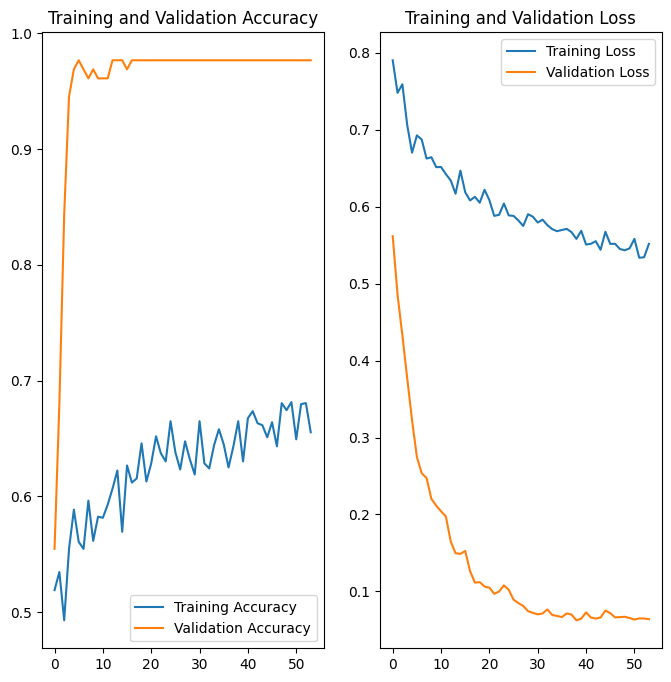

In [42]:
epochs = len(acc)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs),acc,label='Training Accuracy')
plt.plot(range(epochs),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(epochs),loss,label='Training Loss')
plt.plot(range(epochs),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [57]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,556,933 (21.20 MB)

 Trainable params: 1,608,449 (6.14 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,216,900 (12.27 MB)

In [58]:
import numpy as np

first image to predict
actual label: defected slices
predicted label: defected slices


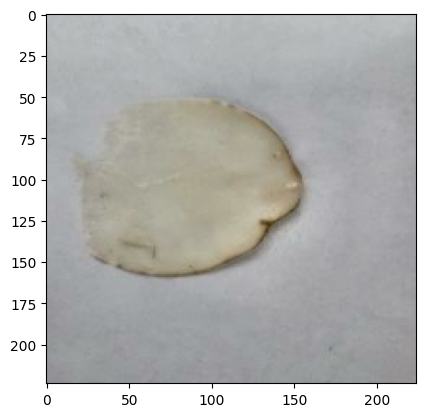

In [59]:
for images_batch,labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    batch_prediction = model.predict(images_batch, verbose=0)
    # For sigmoid output, convert probability to binary class (0 or 1)
    predicted_label_index = (batch_prediction[0][0] > 0.5).astype(int)
    print("predicted label:",class_names[predicted_label_index])

In [62]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(img) # Use the 'img' argument
    img_array = tf.expand_dims(img_array,0)

    predictions = model.predict(img_array, verbose=0)
    # For binary classification with sigmoid, predictions[0] is a single probability
    predicted_label_index = (predictions[0][0] > 0.5).astype(int)
    predicted_class = class_names[predicted_label_index]

    # Calculate confidence for the predicted class
    if predicted_label_index == 1: # If predicted as 'healthy slices'
        confidence = round(100 * predictions[0][0], 2)
    else: # If predicted as 'defected slices'
        confidence = round(100 * (1 - predictions[0][0]), 2)

    return predicted_class,confidence

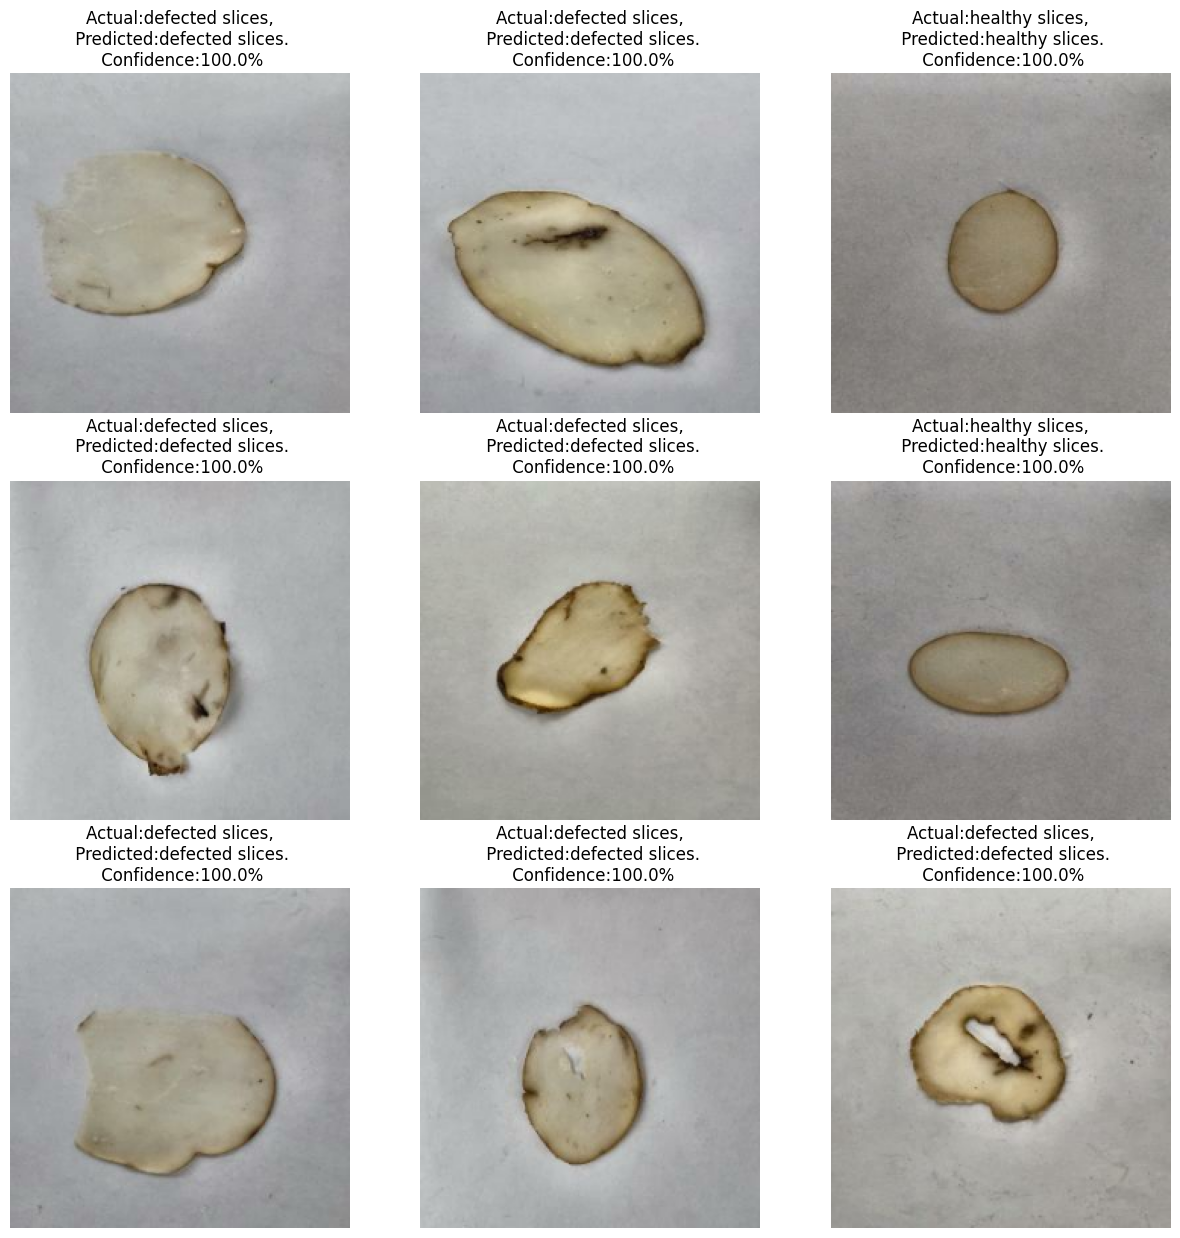

In [64]:
for images , labels in test_ds.take(1):
    plt.figure(figsize=(15,15))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.axis("off")
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class,confidence = predict(model,images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual:{actual_class},\n Predicted:{predicted_class}.\n Confidence:{confidence}%")